## Exploratory Analisys

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import io

In [2]:
data = pd.read_csv('sensors.csv', sep = ',')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6928 entries, 0 to 6927
Data columns (total 95 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 6927 non-null   object 
 1   Total Voltage (V)    6927 non-null   object 
 2   Average Voltage (V)  6927 non-null   float64
 3   sensor 1             6927 non-null   float64
 4   sensor 2             6927 non-null   float64
 5   sensor 3             6927 non-null   float64
 6   sensor 4             6927 non-null   float64
 7   sensor 5             6927 non-null   float64
 8   sensor 6             6927 non-null   float64
 9   sensor 7             6927 non-null   float64
 10  sensor 8             6927 non-null   float64
 11  sensor 9             6927 non-null   float64
 12  sensor 10            6927 non-null   float64
 13  sensor 11            6927 non-null   float64
 14  sensor 12            6927 non-null   float64
 15  sensor 13            6927 non-null   f

In [3]:
#Dropping columns that are not relevant for the model  
data = data.drop(columns = ['Total Voltage (V)', 'Average Voltage (V)'])

#Converting the 'Date' column to datetime format
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)


#Checking the first few rows of the updated dataset
data.head(3)

,Date,sensor 1,sensor 2,sensor 3,sensor 4,sensor 5,sensor 6,sensor 7,sensor 8,sensor 9,...,sensor 83,sensor 84,sensor 85,sensor 86,sensor 87,sensor 88,sensor 89,sensor 90,sensor 91,sensor 92
0,2023-04-03 03:00:01,119.121812,115.827723,116.327884,117.658852,117.589612,117.496657,115.859532,114.603809,118.058141,...,115.647812,114.299245,116.471634,115.380364,115.110607,115.910664,117.049984,114.031306,113.770388,115.565692
1,2023-04-03 04:00:01,121.092423,117.628034,118.118468,119.575351,119.504139,119.387818,117.598619,116.261870,119.998991,...,117.329442,115.892439,118.243012,117.071528,116.750911,117.634598,118.956594,115.616289,115.338720,117.255179
2,2023-04-03 05:00:01,121.893561,118.410648,118.866724,120.405980,120.332878,120.213393,118.315624,116.951690,120.807357,...,118.087727,116.615680,119.053043,117.826122,117.492186,118.392878,119.695606,116.356843,116.066697,118.036934


The fig above show when the site shutdown, and thats it's not a good messure to bring to the model

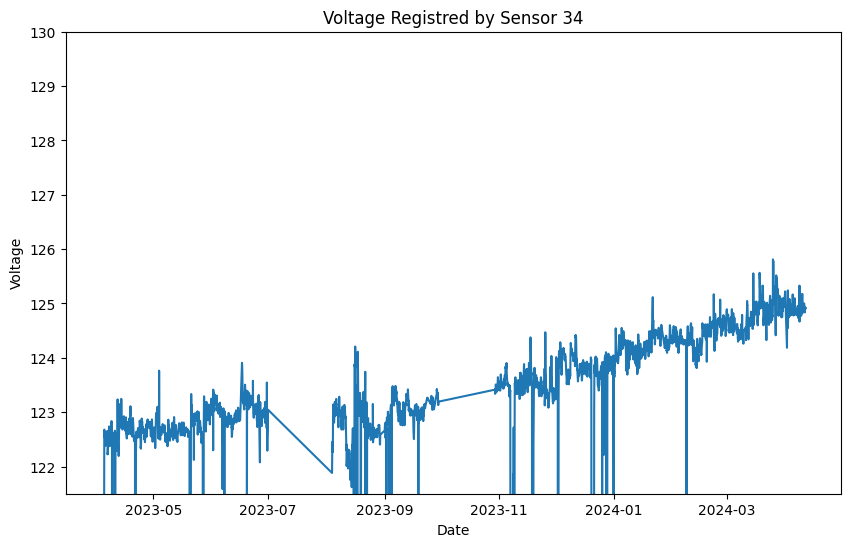

In [4]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = data, y='sensor 34', x='Date')
plt.title('Voltage Registred by Sensor 34')
plt.ylim(121.5, 130)
plt.xlabel('Date')
plt.ylabel('Voltage')
plt.show()

In [5]:
data = data[data['sensor 34'] > 121.5 ]
data['sensor 34'].describe()

count    6658.000000
mean      123.555389
std         0.805674
min       121.585035
25%       122.852568
50%       123.424118
75%       124.263571
max       125.811034
Name: sensor 34, dtype: float64

In [6]:
average_s34 = data.groupby(data['Date'].dt.date)['sensor 34'].mean()
average_s34 = average_s34.reset_index()
average_s34.rename(columns={'Date': 'average_daily'}, inplace=True)
average_s34

,average_daily,sensor 34
0,2023-04-04,122.444449
1,2023-04-05,122.511457
2,2023-04-06,122.462247
3,2023-04-07,122.558795
4,2023-04-08,122.635337
...,...,...
301,2024-04-07,124.854037
302,2024-04-08,125.114604
303,2024-04-09,124.935289
304,2024-04-10,124.929781


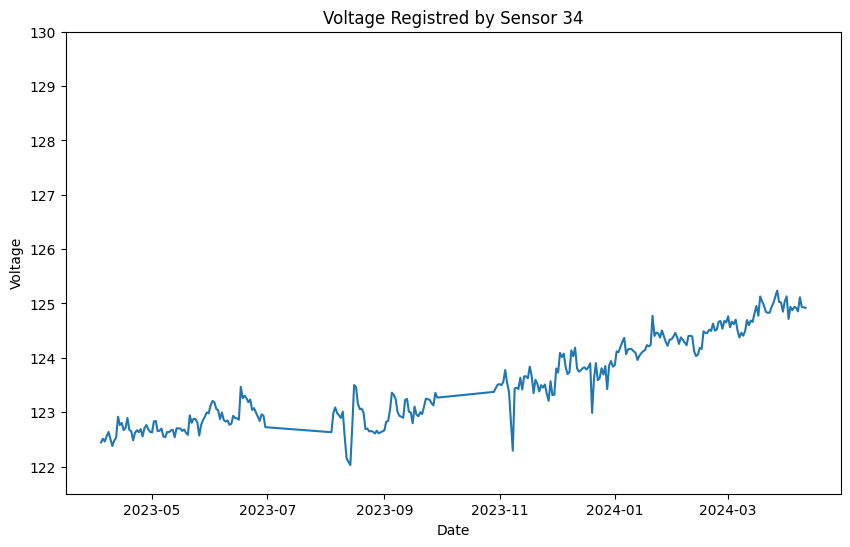

In [7]:
plt.figure(figsize=(10, 6))
sns.lineplot(data = average_s34, x='average_daily', y='sensor 34')
plt.title('Voltage Registred by Sensor 34')
plt.ylim(121.5, 130)
plt.xlabel('Date')
plt.ylabel('Voltage')
plt.show()

In [8]:
average_s34['diff'] = average_s34['sensor 34'].diff()
average_s34.dropna(inplace=True)
average_s34.head(3)

,average_daily,sensor 34,diff
1,2023-04-05,122.511457,0.067008
2,2023-04-06,122.462247,-0.049210
3,2023-04-07,122.558795,0.096548


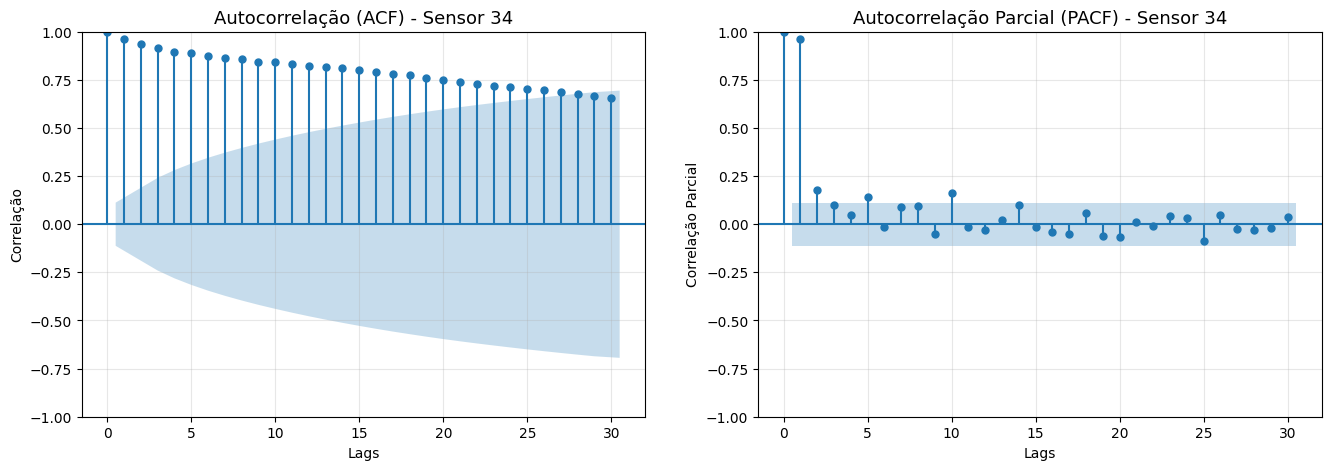

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(average_s34['sensor 34'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelação (ACF) - Sensor 34', fontsize=13)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Correlação')
axes[0].grid(True, alpha=0.3)

plot_pacf(average_s34['sensor 34'], lags=30, method='yw', ax=axes[1], alpha=0.05)
axes[1].set_title('Autocorrelação Parcial (PACF) - Sensor 34', fontsize=13)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlação Parcial')
axes[1].grid(True, alpha=0.3)

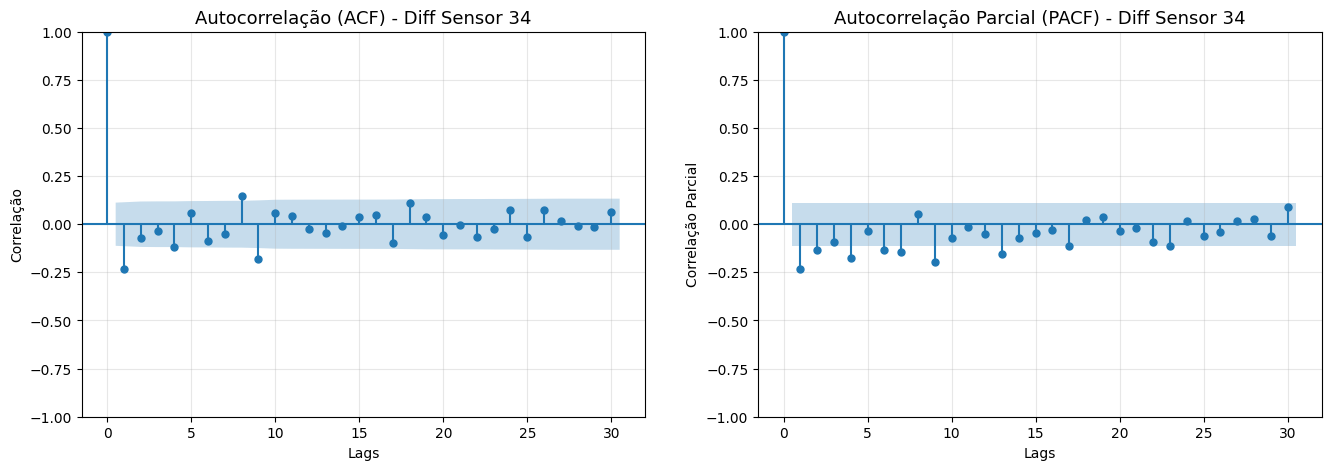

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(average_s34['diff'], lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('Autocorrelação (ACF) - Diff Sensor 34', fontsize=13)
axes[0].set_xlabel('Lags')
axes[0].set_ylabel('Correlação')
axes[0].grid(True, alpha=0.3)

plot_pacf(average_s34['diff'], lags=30, method='yw', ax=axes[1], alpha=0.05)
axes[1].set_title('Autocorrelação Parcial (PACF) - Diff Sensor 34', fontsize=13)
axes[1].set_xlabel('Lags')
axes[1].set_ylabel('Correlação Parcial')
axes[1].grid(True, alpha=0.3)

## Features

Separating into test and training sets

In [11]:
for i in range(1, 4, 1):
        average_s34[f'shift_{i}'] = average_s34['sensor 34'].shift(i)
average_s34.dropna(inplace=True)

y = average_s34['sensor 34'].values.reshape(-1, 1).astype('float32')
X = average_s34[[f'shift_{i}' for i in range(1, 4)]].values.astype('float32')  # Usando os valores dos 8 dias anteriores como recursos


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False) #shuffle=False to maintain the time series order


In [12]:
preview = pd.DataFrame(X_train, columns=[f'shift_{i}' for i in range(1, 4)])
preview.head(3)

,shift_1,shift_2,shift_3
0,122.558792,122.462250,122.511459
1,122.635338,122.558792,122.462250
2,122.505692,122.635338,122.558792


In [13]:
X.shape, y.shape

((302, 3), (302, 1))

Normalizando dados

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) #Evitar datalake

Hiperparâmetros

In [15]:
TAXA_APRENDIZADO = 0.05  # Tamanho do "passo" na otimização (ex: 0.1, 0.01, 0.001)
EPOCAS = 100             # Quantas vezes a rede verá todo o dataset
TAMANHO_LOTE = 3         # Batch size 

Aplicando o treinamento

In [16]:
#Construção da arquitetura
model_simples = Sequential([Dense(1, # 1 Neurônio nesta camada (Z = W*X + b)
                                  input_shape=(3,), # Quantidade de variáveis que vão entrar ( Z = w1*x1 + w2*x2 + b)
                                  activation='linear') ]) # Especificando qual vai ser o tipo de ativação. Ex: reLu, linear, tanh, sigmoid...


#Configuração
model_simples.compile(
    optimizer=Adam(learning_rate=TAXA_APRENDIZADO), #Aplicação do modelo de Gradiente descendente, usando o leanning rate proposto
    loss='mse', # Qual a função da loss. Nesse caso o mse é (Z - F(x1,x2))²
    metrics=['mae'] # Erro Médio Absoluto para termos uma métrica mais legível
)

#Treinamento
historico = model_simples.fit(
    X_train_scaled, y_train, #Indica quais são as bases
    epochs=EPOCAS, batch_size=TAMANHO_LOTE, #O batch_size é a batelada de cada iteração (epoch) que será calculada
    verbose=1 # Mude para 1 se quiser ver o log de cada época
)

Epoch 1/100


c:\Projeto de Manutenção\Maintenance-prediction\.venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 14729.5811 - mae: 121.3514  
Epoch 2/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 13769.6230 - mae: 117.3368  
Epoch 3/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 12862.8223 - mae: 113.4048
Epoch 4/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11999.2832 - mae: 109.5328  
Epoch 5/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 11181.2197 - mae: 105.7306  
Epoch 6/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10401.3535 - mae: 101.9791  
Epoch 7/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 9665.8301 - mae: 98.3085  
Epoch 8/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8972.1611 - mae: 94.7125  
Epoch 9/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8308.8633 - mae: 91.1466  
Epoch 10/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7684.5137 - mae: 87.6554  
Epoch 11/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 7098.4482 - mae: 84.2460
Epoch 12/100
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [17]:
model_simples.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14 (60.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10 (44.00 B)

In [18]:
# get_weights() retorna uma lista: o primeiro item é a matriz de pesos (W), o segundo é o viés (b)
pesos, vies = model_simples.get_layer(index=0).get_weights()

print(f"pesos: {pesos.flatten()} e o viés: {vies[0]:.4f}")

pesos: [0.45589218 0.04107927 0.09926677] e o viés: 123.2977


In [19]:
medias = scaler.mean_
desvios = scaler.scale_

#w = pesos / desvios
w = pesos / desvios[:, np.newaxis]
b_raw = vies - np.dot(medias, w)

w_escalar = w[0][0]
b_raw_escalar = b_raw[0]

print(f"Pesos desnormalizados: {w.flatten()}")
print(f"Viés desnormalizado: {b_raw_escalar:.4f}")

Pesos desnormalizados: [0.76261747 0.06895286 0.16695557]
Viés desnormalizado: 0.1984


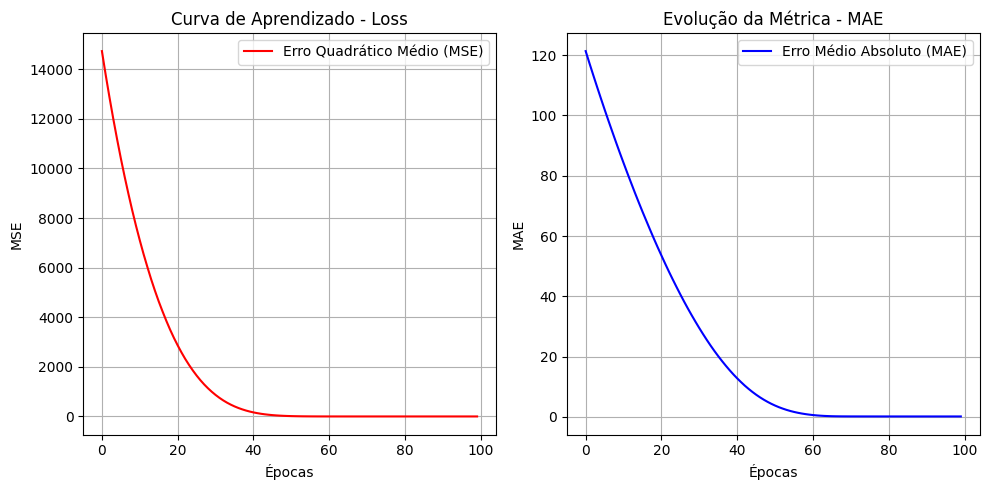

In [20]:
plt.figure(figsize=(10, 5))

# Plotando a Perda (MSE)
plt.subplot(1, 2, 1)
plt.plot(historico.history['loss'], label='Erro Quadrático Médio (MSE)', color='red')
plt.title('Curva de Aprendizado - Loss')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)

# Plotando a Métrica (MAE)
plt.subplot(1, 2, 2)
plt.plot(historico.history['mae'], label='Erro Médio Absoluto (MAE)', color='blue')
plt.title('Evolução da Métrica - MAE')
plt.xlabel('Épocas')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [21]:
erro_simples = model_simples.evaluate(X_test_scaled, y_test, verbose=0)[1]
print(f"Erro Médio Absoluto (Simples): {erro_simples:.2f}\n")

Erro Médio Absoluto (Simples): 0.11



2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


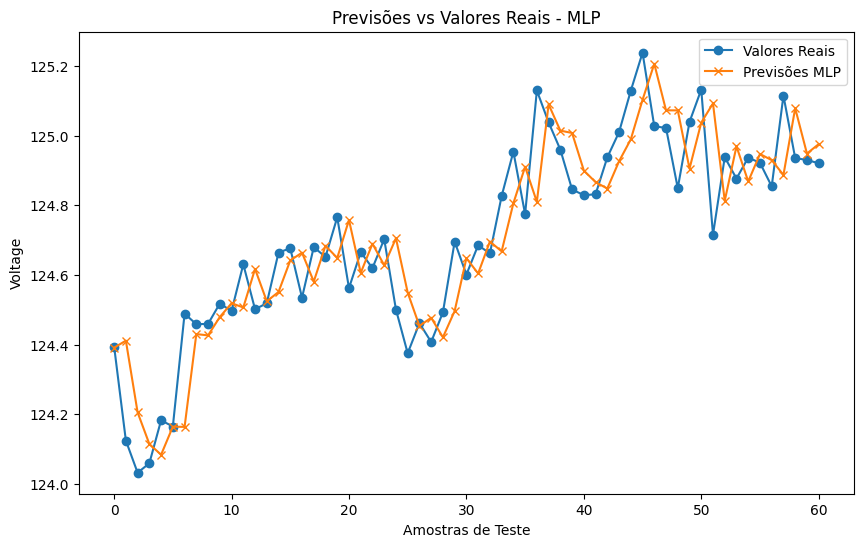

In [22]:
plt.figure(figsize=(10, 6))
y_pred = model_simples.predict(X_test_scaled)   
plt.plot(y_test, label='Valores Reais', marker='o')
plt.plot(y_pred, label='Previsões MLP', marker='x')
plt.title('Previsões vs Valores Reais - MLP')
plt.xlabel('Amostras de Teste')
plt.ylabel('Voltage')
plt.legend()

O Veredito sobre os seus Dados
Isso nos dá uma conclusão técnica valiosíssima sobre o problema de Voltagem que você está tentando resolver: A natureza desse fenômeno é estritamente linear.

A relação entre as Voltagens passadas e a Voltagem futura não tem segredos complexos, curvas acentuadas ou interações ocultas. É uma proporção direta. Quando você tentou forçar uma arquitetura complexa (Deep Learning com ReLU) para resolver um problema simples, o modelo tentou achar padrões onde só existia ruído (overfitting), resultando naquela curva laranja que explodia.

Quando você voltou para o linear, o modelo respirou aliviado e traçou a reta perfeita.